# Task 2 - Lasso / elastic net vs ridge on identical data
Run `python3 -m src.task1_ridge` then `python3 -m src.task2_alternative` first.

In [6]:
# Run from the notebooks/ folder or the repo root; all logic lives in src/.
import sys, pathlib
ROOT = pathlib.Path.cwd() if (pathlib.Path.cwd() / "src").exists() else pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
TABLES, FIGS = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"

In [7]:
t2 = pd.read_csv(TABLES / "task2_summary.csv")
t2.pivot(index="cq", columns="model", values="sharpe_paper_mean").round(4)

model,elastic_net,lasso
cq,,
0.50,0.0044,0.0021
0.75,0.0033,0.0027
0.90,0.0035,0.0023
0.95,0.0041,0.0026
0.98,0.0039,0.0015
1.02,0.0033,0.0015
1.05,0.0030,0.0029
1.10,0.0036,0.0016
1.25,0.0045,0.0033


## Sparsity versus the dense true signal

In [8]:
t2.pivot(index="cq", columns="model", values="n_nonzero_mean").round(1)

model,elastic_net,lasso
cq,,
0.50,7.1,4.6
0.75,4.8,4.1
0.90,6.3,4.5
0.95,6.2,5.0
0.98,7.0,4.9
1.02,7.7,5.3
1.05,8.0,6.8
1.10,8.2,5.9
1.25,8.5,6.3


## Selected hyper-parameters (training-only validation)

In [9]:
pd.read_csv(TABLES / "task2_selected_hyperparameters.csv").head(30)

,cq,model,alpha_median,l1_ratio_median,alpha_min,alpha_max
0,0.50,elastic_net,0.30,0.50,0.1,1.0
1,0.50,lasso,1.00,1.00,0.1,1.0
2,0.75,elastic_net,1.00,0.25,0.1,1.0
3,0.75,lasso,1.00,1.00,0.1,1.0
4,0.90,elastic_net,1.00,0.25,0.1,1.0
5,0.90,lasso,1.00,1.00,0.1,1.0
6,0.95,elastic_net,1.00,0.50,0.1,1.0
7,0.95,lasso,1.00,1.00,0.1,1.0
8,0.98,elastic_net,1.00,0.50,0.1,1.0
9,0.98,lasso,1.00,1.00,0.1,1.0


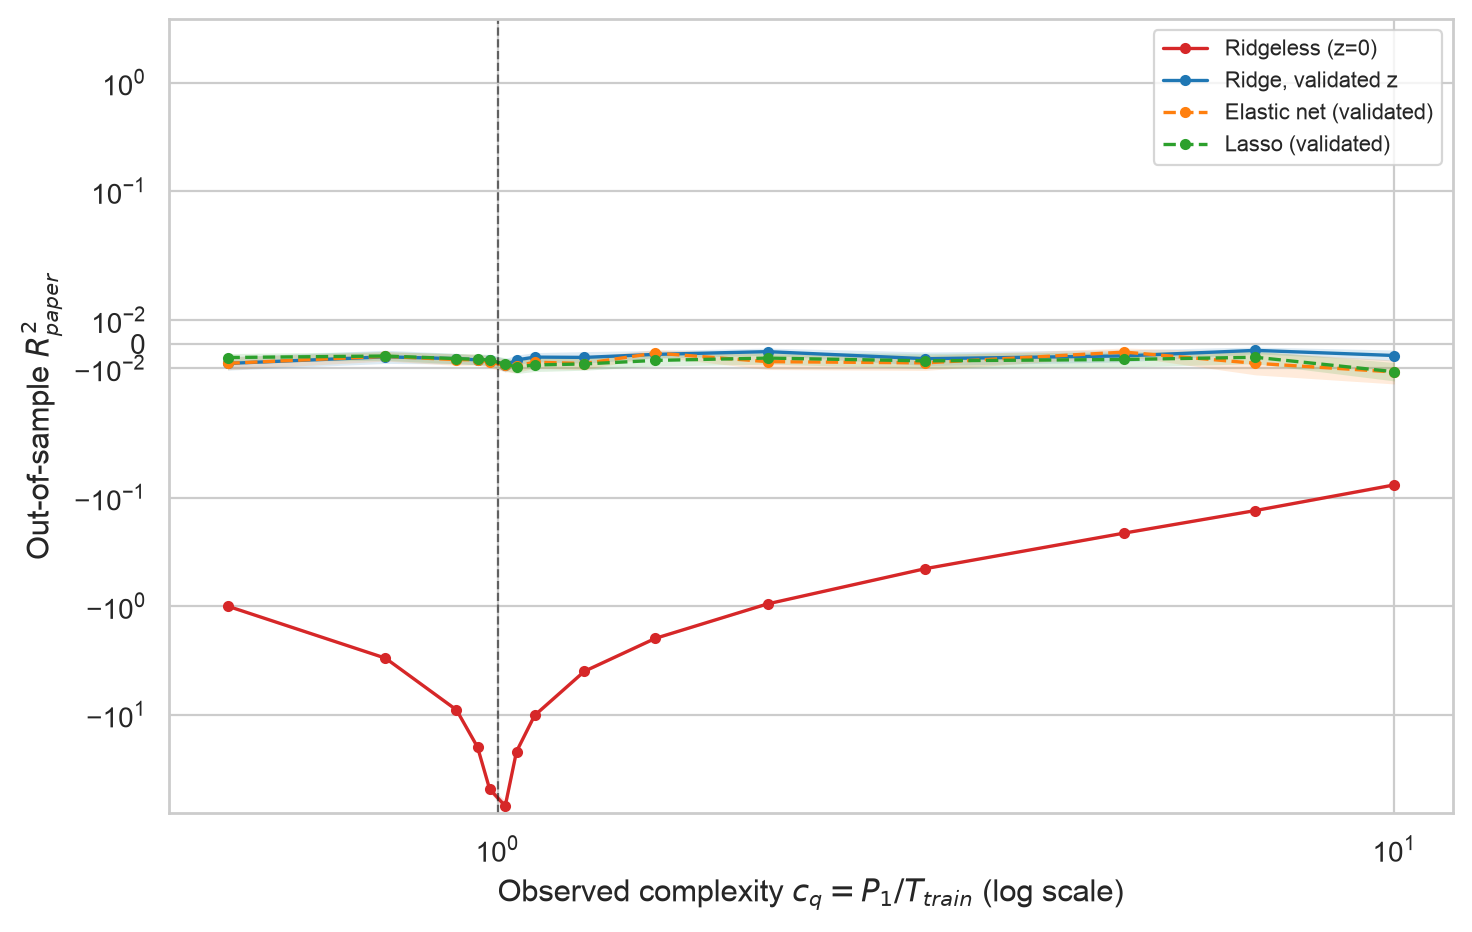

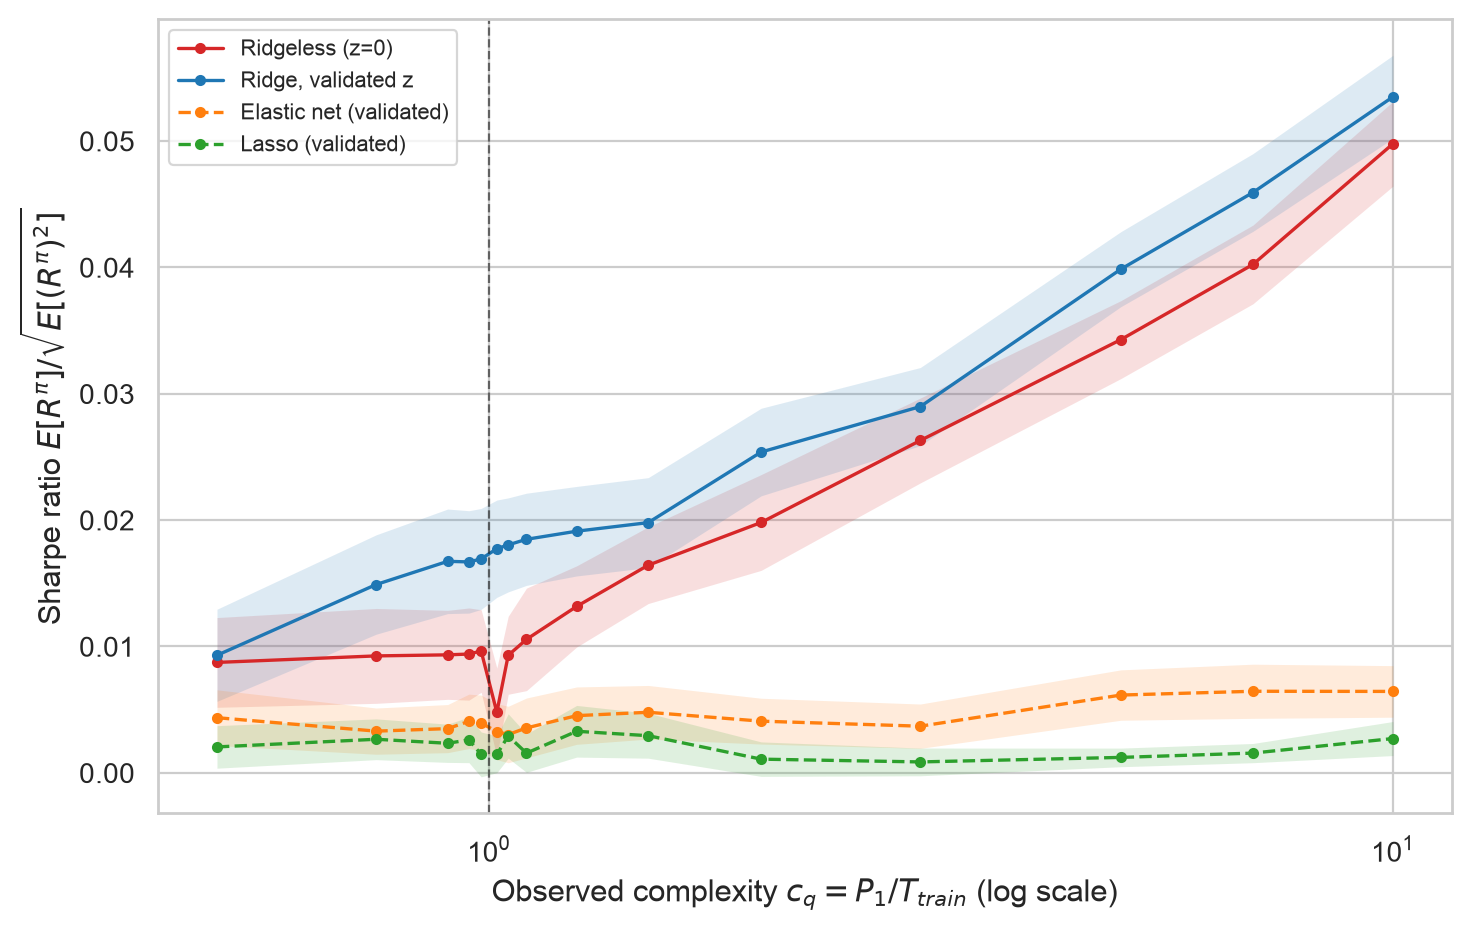

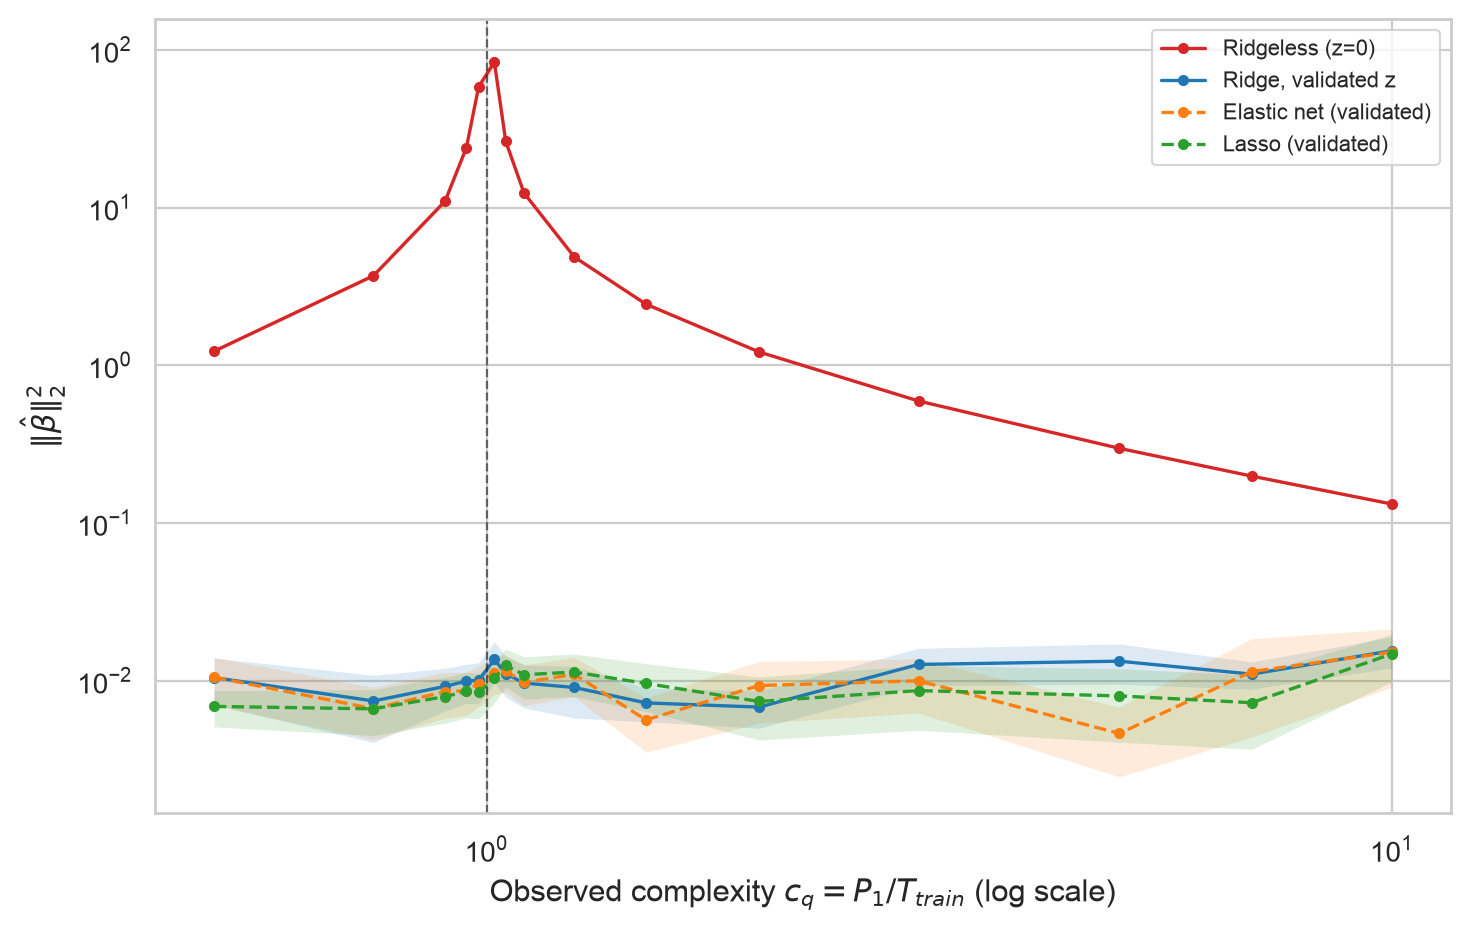

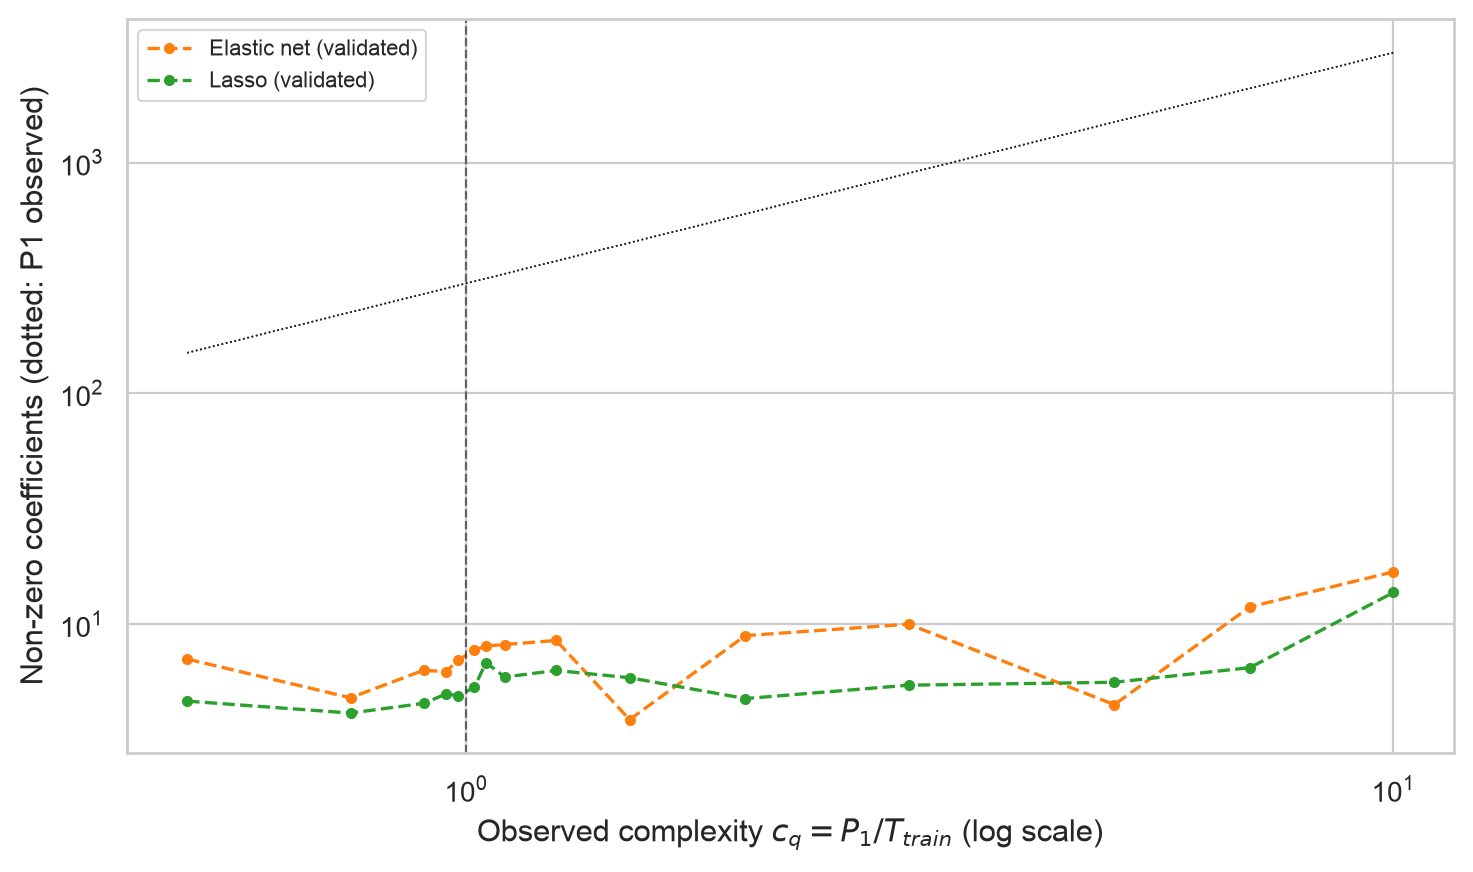

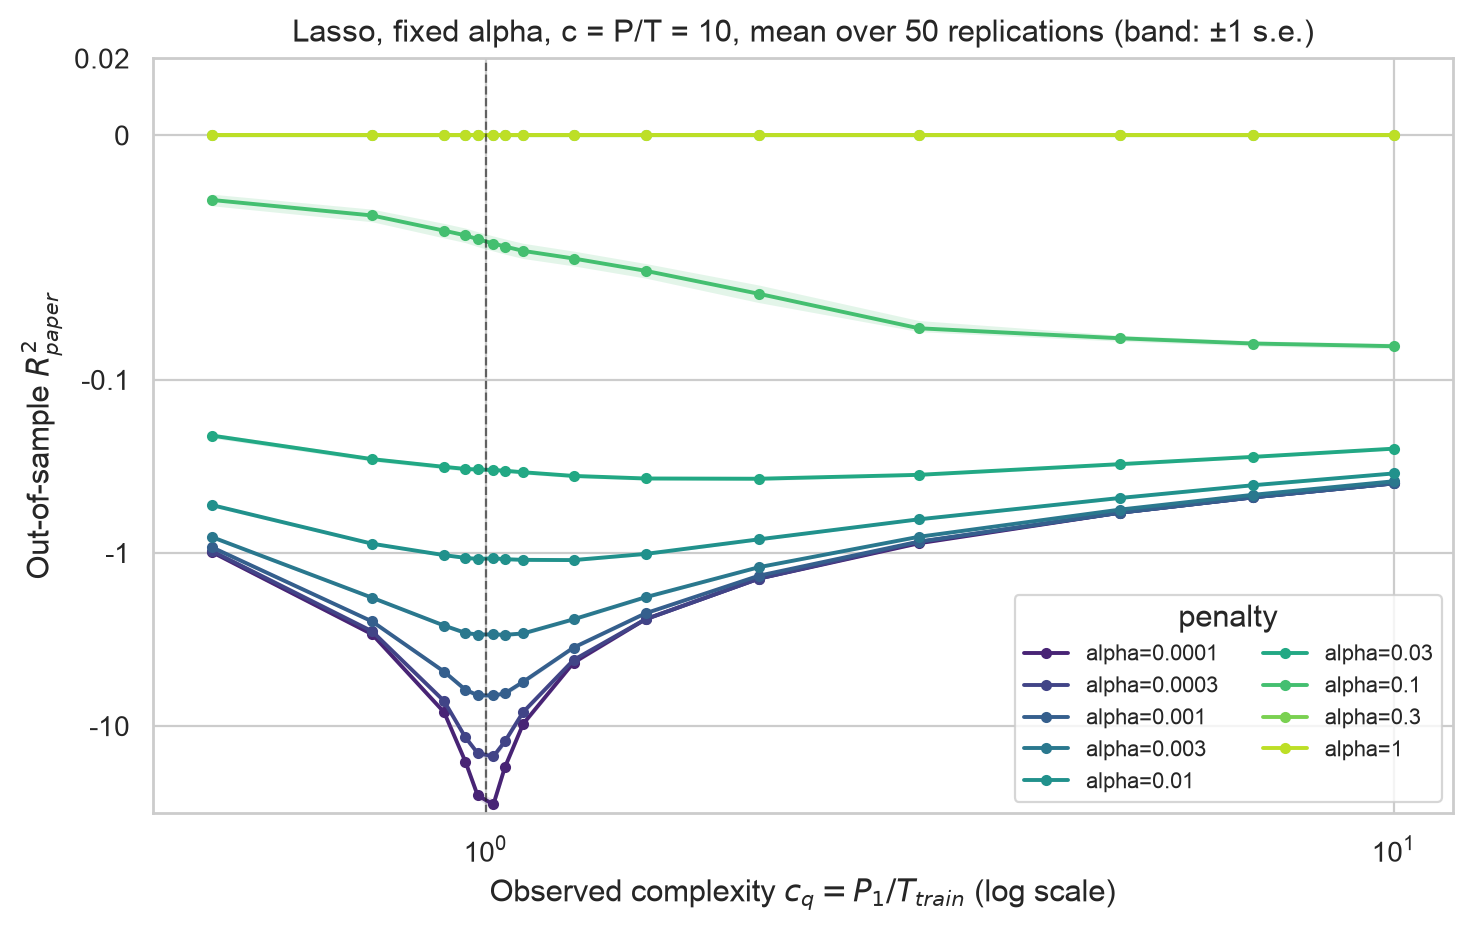

In [10]:
for f in ["task2_ridge_vs_alternative_r2", "task2_ridge_vs_alternative_sharpe", "task2_ridge_vs_alternative_beta_norm", "task2_sparsity_vs_cq", "task2_lasso_fixed_alpha_r2_vs_cq"]:
    display(Image(FIGS / f"{f}.png"))